In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


# DATASET

In [56]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class BananaDataset(Dataset):
    def __init__(self, root_dir, max_per_day=50):
        self.samples = []
        self.max_day = 6

        self.transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.ToTensor(),
        ])

        for folder in os.listdir(root_dir):
            if not folder.startswith("Day"):
                continue

            # Extract day number safely
            day = int(folder.split(" ")[1])

            folder_path = os.path.join(root_dir, folder)

            count = 0  # limit per day

            for img in os.listdir(folder_path):
                if count >= max_per_day:
                    break

                img_path = os.path.join(folder_path, img)

                # Only image files
                if not img_path.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                self.samples.append((img_path, day))
                count += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, day = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        # Normalize time (0–1)
        t = torch.tensor([day / self.max_day], dtype=torch.float32)

        # Ripeness (same as time for now)
        R = torch.tensor([day / self.max_day], dtype=torch.float32)

        return image, t, R

# MODELS

In [69]:
import torch
import torch.nn as nn

class CNN_Baseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.flatten = nn.Flatten()

        self.feature_size = 16 * 4 * 4

        self.fc = nn.Sequential(
            nn.Linear(self.feature_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        f = self.cnn(x)
        f = self.flatten(f)
        return self.fc(f)

In [ ]:
import torch
import torch.nn as nn

class FastCNN_PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # KEY FIX
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.flatten = nn.Flatten()

        self.feature_size = 16 * 4 * 4   # FIXED NOW

        self.k = nn.Parameter(torch.tensor(0.5))

        self.fc = nn.Sequential(
            nn.Linear(self.feature_size + 1, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x, t):
        f = self.cnn(x)
        f = self.flatten(f)

        x = torch.cat([f, t], dim=1)
        return self.fc(x)

# LOSS

In [61]:
def data_loss(R_pred, R_true):
    return torch.mean((R_pred - R_true) ** 2)


def physics_loss(model, images, t):
    t.requires_grad_(True)

    R = model(images, t)

    dR_dt = torch.autograd.grad(
        R, t,
        grad_outputs=torch.ones_like(R),
        create_graph=True
    )[0]

    k = torch.abs(model.k)

    residual = dR_dt - k * (1 - R)

    return torch.mean(residual ** 2)

# Training Loop

In [62]:
def data_loss(R_pred, R_true):
    return torch.mean((R_pred - R_true) ** 2)


def physics_loss(model, images, t):
    t.requires_grad_(True)

    R = model(images, t)

    dR_dt = torch.autograd.grad(
        R, t,
        grad_outputs=torch.ones_like(R),
        create_graph=True
    )[0]

    k = torch.abs(model.k)

    residual = dR_dt - k * (1 - R)

    return torch.mean(residual ** 2)

# TRAIN

In [70]:
def train_baseline(model, dataloader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0

        for images, t, R_true in dataloader:
            optimizer.zero_grad()

            R_pred = model(images)

            loss = torch.mean((R_pred - R_true) ** 2)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[CNN] Epoch {epoch+1}, Loss={total_loss:.4f}")

In [ ]:
def train_fast(model, dataloader, epochs=5, lambda_phy=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        total_loss = 0

        for step, (images, t, R_true) in enumerate(dataloader):
            optimizer.zero_grad()

            R_pred = model(images, t)
            loss_data = torch.mean((R_pred - R_true) ** 2)

            #  FAST physics (subset + interval)
            if step % 3 == 0:
                images_phy = images[:2]
                t_phy = t[:2]
                loss_phy = physics_loss(model, images_phy, t_phy)
            else:
                loss_phy = 0

            loss = loss_data + lambda_phy * loss_phy

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss={total_loss:.4f}")

# TEST


In [74]:
def test_model(model, dataloader, pinn=True):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, t, R_true in dataloader:
            if pinn:
                R_pred = model(images, t)
            else:
                R_pred = model(images)

            loss = torch.mean((R_pred - R_true) ** 2)
            total_loss += loss.item()

    print("Test Loss:", total_loss)

    return total_loss

# RUN

In [65]:
dataset = BananaDataset("/content/drive/MyDrive/REAL_TIME_BANANA_DATASET")

print("Total samples:", len(dataset))

img, t, R = dataset[0]

print("Image shape:", img.shape)
print("Time:", t)
print("Ripeness:", R)

Total samples: 300
Image shape: torch.Size([3, 96, 96])
Time: tensor([1.])
Ripeness: tensor([1.])


In [66]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [67]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [71]:
model_cnn = CNN_Baseline()

train_baseline(model_cnn, train_loader, epochs=5)

[CNN] Epoch 1, Loss=4.5976
[CNN] Epoch 2, Loss=4.4082
[CNN] Epoch 3, Loss=4.3156
[CNN] Epoch 4, Loss=3.7896
[CNN] Epoch 5, Loss=2.7712


In [75]:
cnn_loss = test_model(model_cnn, test_loader, pinn=False)

print("CNN Test Loss:", cnn_loss)

Test Loss: 0.7623024447821081
CNN Test Loss: 0.7623024447821081


In [68]:
model_pinn = FastCNN_PINN()

train_fast(model_pinn, train_loader, epochs=5)

Epoch 1, Loss=4.2105
Epoch 2, Loss=3.5348
Epoch 3, Loss=2.1687
Epoch 4, Loss=0.8537
Epoch 5, Loss=0.4915


In [76]:
pinn_loss = test_model(model_pinn, test_loader, pinn=True)
print("PINN Test Loss:", pinn_loss)

Test Loss: 0.1554113764432259
PINN Test Loss: 0.1554113764432259


# GRAPHICAL DIFFERENCE

In [ ]:
def compare_curves_real(model_cnn, model_pinn, dataset):
    import matplotlib.pyplot as plt
    import torch

    model_cnn.eval()
    model_pinn.eval()

    # take real image
    image, _, _ = dataset[0]
    image = image.unsqueeze(0)

    t_vals = torch.linspace(0, 1, 50).unsqueeze(1)

    cnn_preds = []
    pinn_preds = []

    for t in t_vals:
        with torch.no_grad():
            cnn_preds.append(model_cnn(image).item())
            pinn_preds.append(model_pinn(image, t.unsqueeze(0)).item())

    plt.figure(figsize=(6,4))
    plt.plot(t_vals.numpy(), cnn_preds, label="CNN Baseline", linestyle="--")
    plt.plot(t_vals.numpy(), pinn_preds, label="PINN Model", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel("Ripeness")
    plt.title("CNN vs PINN (Real Image)")
    plt.legend()
    plt.grid()
    plt.show()

In [83]:
import matplotlib.pyplot as plt

def plot_pred_vs_true(model, dataloader, pinn=True):
    model.eval()

    true_vals = []
    pred_vals = []

    with torch.no_grad():
        for images, t, R_true in dataloader:

            if pinn:
                R_pred = model(images, t)
            else:
                R_pred = model(images)

            true_vals.extend(R_true.squeeze().tolist())
            pred_vals.extend(R_pred.squeeze().tolist())

    plt.figure(figsize=(5,5))
    plt.scatter(true_vals, pred_vals, alpha=0.6)

    # perfect line
    plt.plot([0,1], [0,1], 'r--')

    plt.xlabel("True Ripeness")
    plt.ylabel("Predicted Ripeness")
    plt.title("Predicted vs True Ripeness")

    plt.grid()
    plt.show()

In [84]:
import numpy as np

def plot_daywise(model, dataset, pinn=True):
    model.eval()

    day_preds = {i: [] for i in range(1,7)}

    with torch.no_grad():
        for img, t, R in dataset:
            day = int(t.item() * 6)

            if pinn:
                pred = model(img.unsqueeze(0), t.unsqueeze(0)).item()
            else:
                pred = model(img.unsqueeze(0)).item()

            day_preds[day].append(pred)

    avg = [np.mean(day_preds[d]) for d in range(1,7)]

    plt.plot(range(1,7), avg, marker='o')
    plt.xlabel("Day")
    plt.ylabel("Average Ripeness")
    plt.title("Day-wise Ripeness Trend")
    plt.grid()
    plt.show()

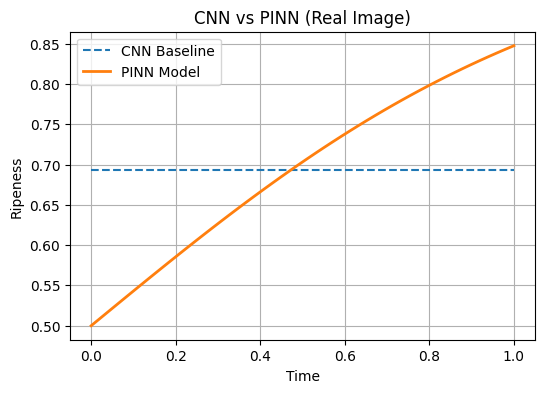

In [82]:
compare_curves_real(model_cnn, model_pinn, dataset)

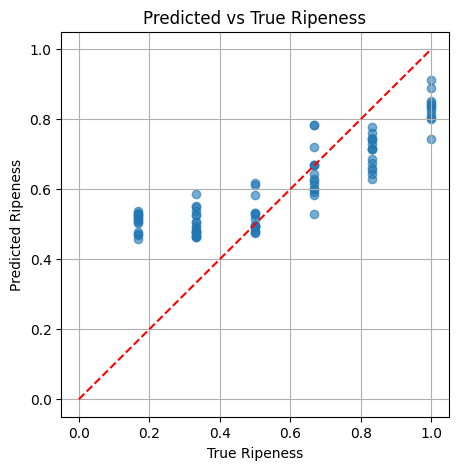

In [85]:
plot_pred_vs_true(model_cnn, test_loader, pinn=False)

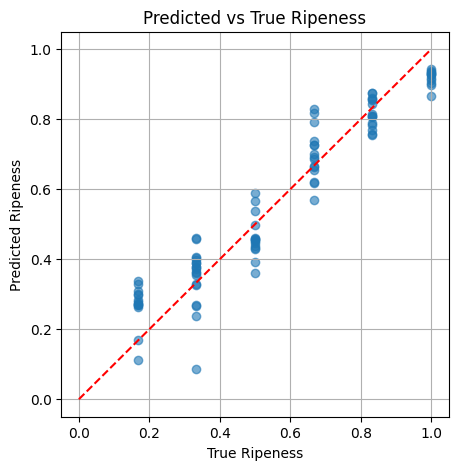

In [86]:
plot_pred_vs_true(model_pinn, test_loader, pinn=True)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


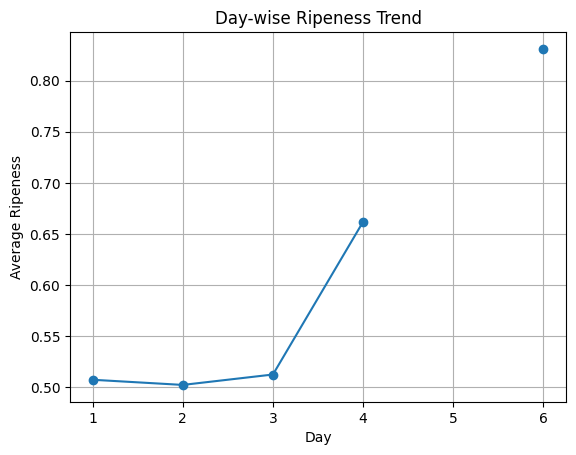

In [88]:
plot_daywise(model_cnn, dataset, pinn=False)

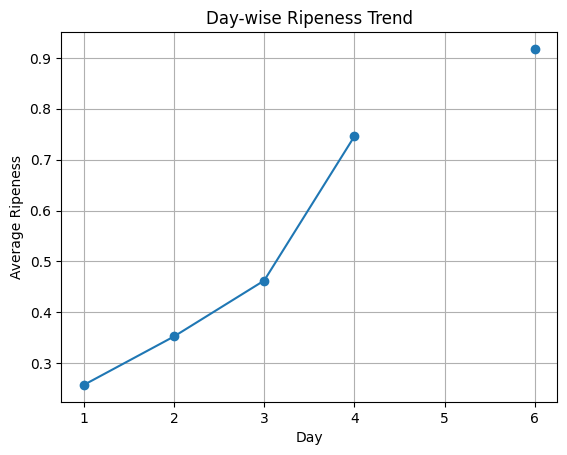

In [89]:
plot_daywise(model_pinn, dataset, pinn=True)